# 1、探究为什么新的质量矩阵和刚度矩阵数值这么大。
## 1.1 猜想由于模态向量数值太小，尝试进行归一化，在进行计算。
## 1.2 实现了质量归一化，和最大值归一化，并未对转换矩阵产生太大的影响。

In [7]:
#import packages
import time
import numpy as np
import capytaine as cpt
import scipy
from capytaine.io.mesh_writers import write_STL
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from scipy.linalg import eigh
import vtk
import logging
import xarray as xr
from capytaine.io.xarray import merge_complex_values
from capytaine.post_pro import rao
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s: %(message)s')
# user defined functions
import DM_ShowNodes as DMshow
import DM_Reading as dm_r
import DM_Assemble as DM_A
import SEREP as SEREP

In [ ]:
# result_reduce = DM_M.perform_RODM_reduce_order_model(num_nodes, node_position_params, hydrodynamic_data_path, structure_data_paths,use_hydrostatic=False)
result_expaned = DM_M.perform_expansion_and_solve(num_nodes, node_position_params, hydrodynamic_data_path, structure_data_paths,use_hydrostatic=False)
# result_yuan = DM_M.calculate_initial_displacement(num_nodes, node_position_params, hydrodynamic_data_path, structure_data_paths)

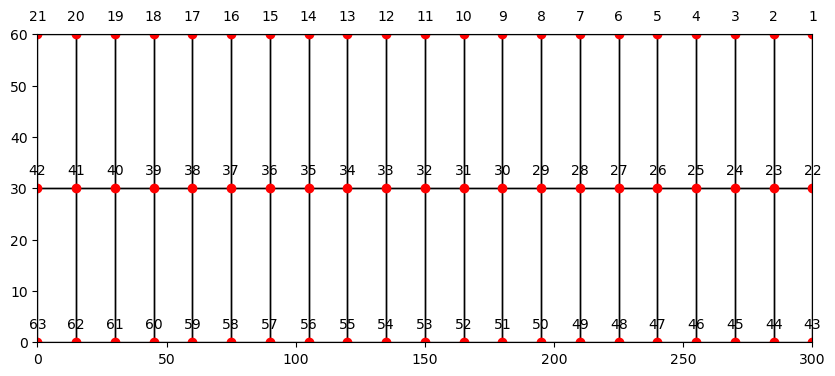

In [8]:
# Show nodes and node message
file_path = "E:\phd\Code\DM-FEM2D\Fem_inp\Job-1_largemesh.inp"
label_interval = 1
node = DMshow.plot_fea_model(file_path, label_interval)
#node_ids = [41, 39, 37, 35, 33, 31, 29, 27, 25, 23]

In [113]:
# define parameters
num_nodes = 63 # 63 793
master_nodes = [41, 39, 37, 35, 33, 31, 29, 27, 25, 23]  #[41, 39, 37, 35, 33, 31, 29, 27, 25, 23] DM_A.calculate_node_positions(425,6,10)
dataset = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\DM10_120_direction0.nc"))
omega = dataset.omega.values
Area = 1025*9.81*30*15
nodes_per_row = 21
# read mass and stiffness matrix
file_m = 'E:\phd\Code\DM-FEM2D\StructureData\Job-1_largemesh_ConsistentMass_MASS1.mtx'
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\Job-1_largemesh_STIF1.mtx' 
M = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)

# reduce dofs
M_consistant= SEREP.reduce_dofs(M, num_nodes, [5])
k = SEREP.reduce_dofs(k, num_nodes, [5])

# transform mass matrix, beta=0 is consistant mass matrix
M = SEREP.transform_mass_matrix(M_consistant,beta=0)
# obtaine master dofs and slave dofs
MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)


from scipy.linalg import eigh
def SEREP1(K, M, SlaveDofs):
    # Sort the SlaveDofs
    SlaveDofs = np.sort(SlaveDofs)
    #矩阵重组
    # Create index array for remaining DOFs
    index = np.setdiff1d(np.arange(K.shape[0]), SlaveDofs)
    M1 = M[index[:, np.newaxis], index]
    M2 = M[index[:, np.newaxis], SlaveDofs]
    M3 = M[SlaveDofs[:, np.newaxis], index]
    M4 = M[SlaveDofs[:, np.newaxis], SlaveDofs]
    k1 = K[index[:, np.newaxis], index]
    k2 = K[index[:, np.newaxis], SlaveDofs]
    k3 = K[SlaveDofs[:, np.newaxis], index]
    k4 = K[SlaveDofs[:, np.newaxis], SlaveDofs]
    M = np.vstack([np.hstack([M1, M2]), np.hstack([M3, M4])])
    K = np.vstack([np.hstack([k1, k2]), np.hstack([k3, k4])])
    # Solve the eigenvalue problem
    eigenvalues, eigenvectors = eigh(K, M)

    # # 对每个模态向量进行归一化
    for i in range(eigenvectors.shape[1]):  # 遍历所有列
        max_val = np.max(np.abs(eigenvectors[:, i]))  # 找到最大的绝对值
        eigenvectors[:, i] /= max_val  # 归一化

    #对每个模态向量进行归一化
    # for i in range(M.shape[1]):
    #     norm_val = np.sqrt(np.dot(eigenvectors[:, i].T, np.dot(M, eigenvectors[:, i])))
    #     eigenvectors[:, i] /= norm_val
    
    # threshold = 1e-10
    # # 清理小数值
    # eigenvectors[np.abs(eigenvectors) < threshold] = 0

    # Define transformation matrices
    T = eigenvectors[:,0:50] @ np.linalg.inv(eigenvectors[0:50,0:50])
    # 设置清理小数值的阈值

    # Calculate the reduced mass and stiffness matrices
    MR = T.T @ M @ T
    KR = T.T @ K @ T
    
    return MR,KR,T,eigenvectors

# reduce matrix use SEREP
MR,KR,T,eigenvectors = SEREP1(k, M, SlaveDofs)


In [115]:
np.linalg.inv(eigenvectors[0:50,0:50]).mean()

-7.308673828125

In [110]:
# read hydrodynamic data
added_mass = dataset['added_mass'][0].values
radiation_damping = dataset['radiation_damping'][0].values
inertia_matrix = dataset['inertia_matrix'].values
# hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
F_w = dataset['Froude_Krylov_force'][0].values + dataset['diffraction_force'][0].values
# REDUCE THE MATRICES
added_mass = SEREP.reduce_dofs(added_mass,10,[5])
radiation_damping = SEREP.reduce_dofs(radiation_damping,10,[5])
# hyrostatic stiffness or fem spring stiffness
# 1. choice hydrostatic stiffness
hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,10,[5])
# 2. choice fem spring stiffness
# hydrostatic_stiffness = SEREP.get_fem_spring_stiffness(num_nodes, nodes_per_row, Area)
# hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,num_nodes,[5])
# hydrostatic_stiffness = T.T @ hydrostatic_stiffness @ T

inertia_matrix = SEREP.reduce_dofs(inertia_matrix,10,[5])
F_w = SEREP.reduce_force_matrix_dofs(F_w, 10, 5).reshape(1,50)
# F_w = F_w.reshape(10,5)[::-1].reshape(1,50)
# Generate the system matrices
mass = added_mass + MR
damping = radiation_damping
stiffness = hydrostatic_stiffness + KR
# Solve in frequency domain
master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, F_w, omega)
# Restore global displacement under disorder masterdofs and slavedofs
global_displacement_disorder = T @ master_displacement
# Reorder global displacement under order
global_displacement = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)

In [49]:
T.min()

-2080802616921097.8

## 验证工作

Text(0, 0.5, 'Heave RAO ($m$/$m$)')

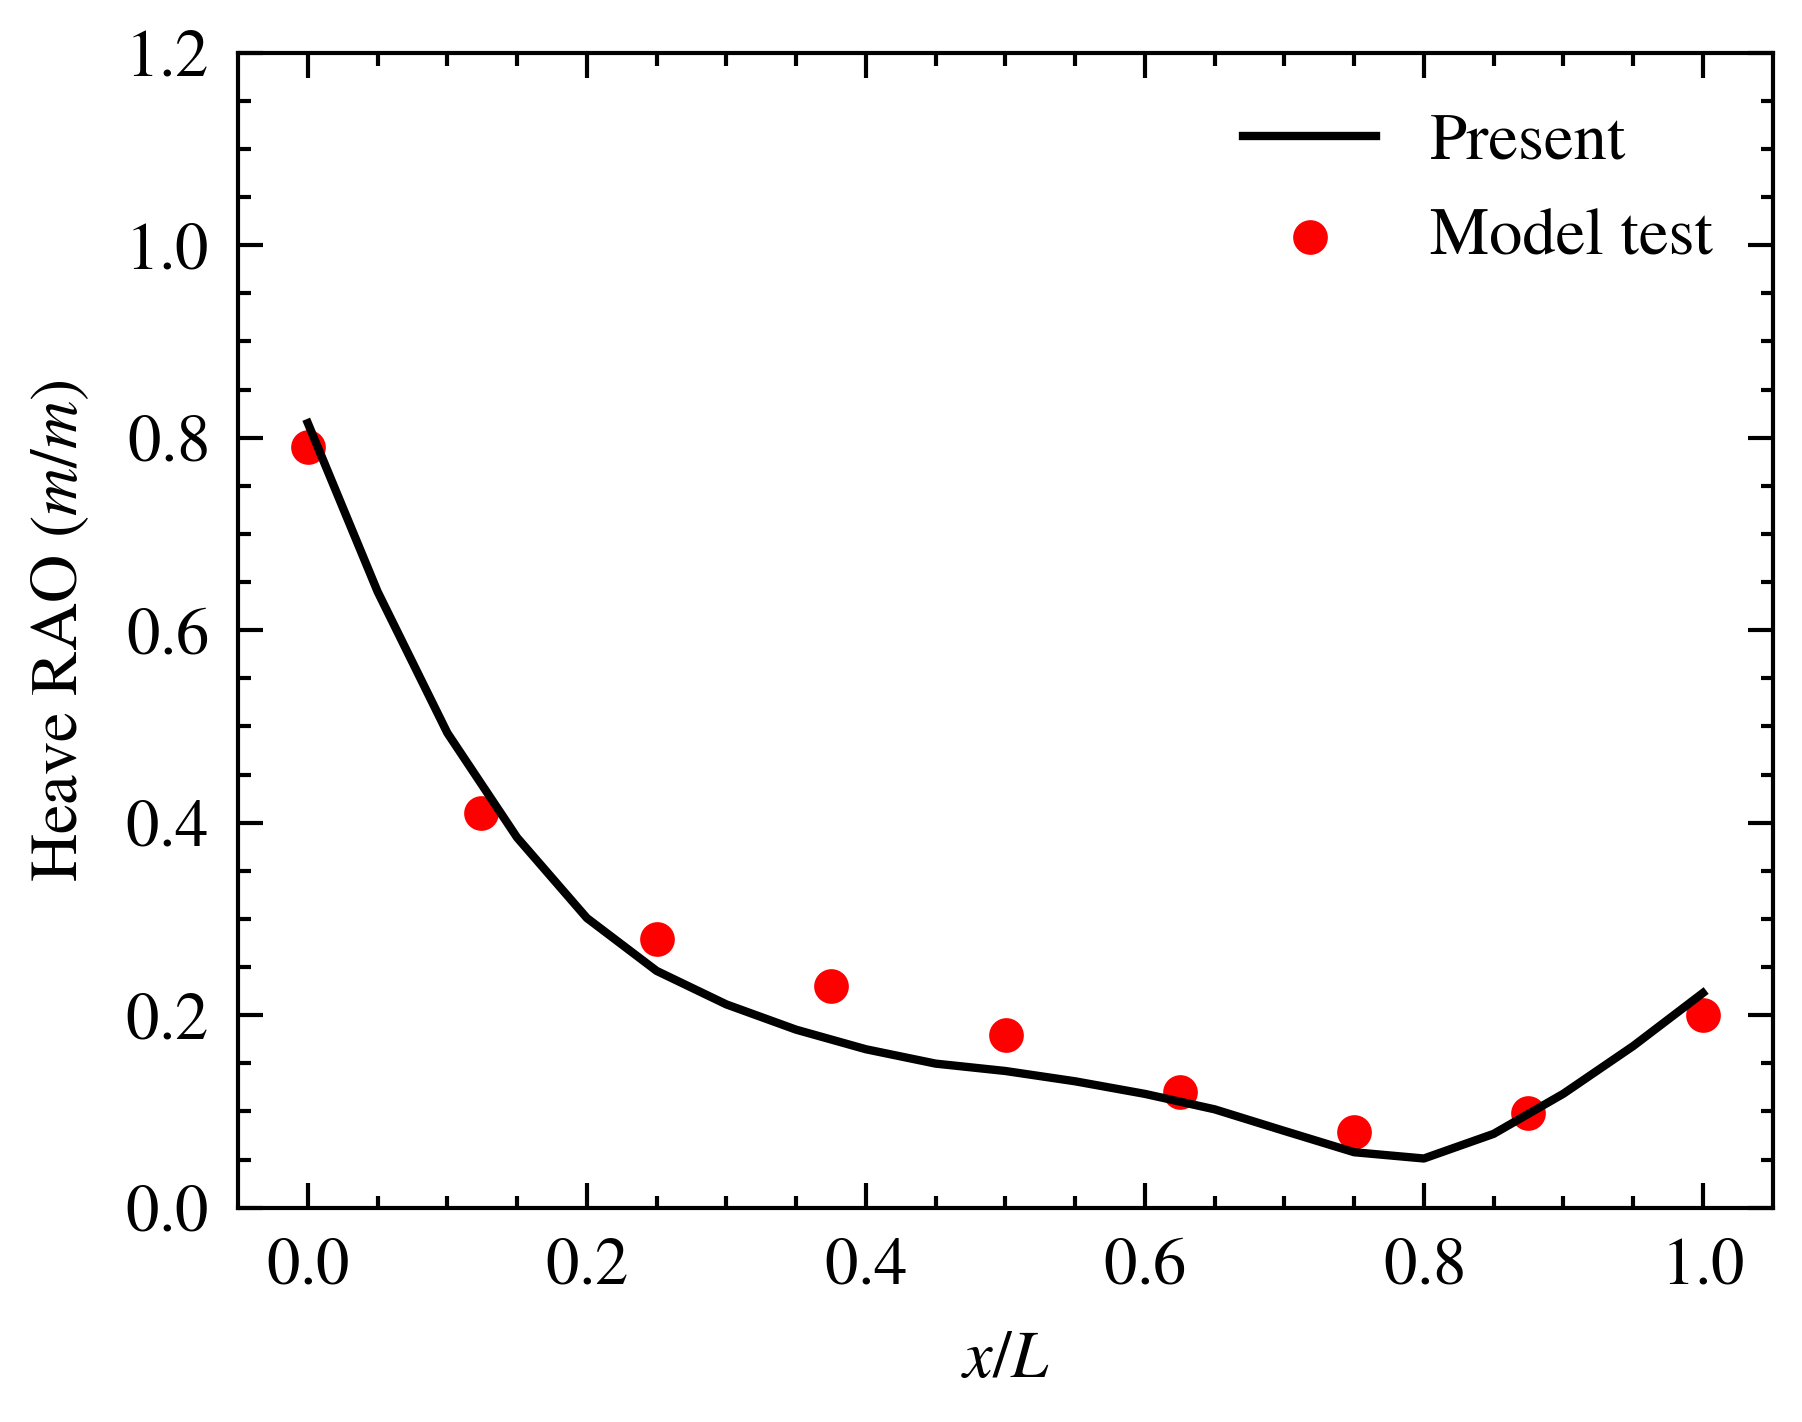

In [111]:
import matplotlib.pyplot as plt
mid = global_displacement[22*5-5:43*5-5,:]
heave = abs(mid[2::5])

# 与实验结果进行对比、绘图
from DM_Verify import process_exp_data
x, y = process_exp_data("E:\phd\Code\DM-FEM2D\data\Experiment_300_60\exp_120.txt")
y = np.array(y)
# 绘图
import scienceplots
x1 = np.linspace(0,1,21)
plt.style.use(['science','no-latex','ieee'])
plt.plot(x1,abs(mid[2::5]), label="Present")
plt.scatter(x,y,color = 'red',label="Model test",s=10)
plt.legend() 
plt.ylim(0,1.2) # 调整y轴坐标
plt.xlabel(r'$x/L$',)
plt.ylabel(r'Heave RAO ($m$/$m$)')

In [ ]:
import matplotlib.pyplot as plt
mid = global_displacement[367*5-5:427*5-5,:]
heave = abs(mid[2::5])

# 与实验结果进行对比、绘图
from DM_Verify import process_exp_data
x, y = process_exp_data("E:\phd\Code\DM-FEM2D\data\Experiment_300_60\exp_120.txt")
y = np.array(y)
# 绘图
import scienceplots
x1 = np.linspace(0,1,60)
plt.style.use(['science','no-latex','ieee'])
plt.plot(x1,abs(mid[2::5]), label="Present")
plt.scatter(x,y[::-1],color = 'red',label="Model test",s=10)
plt.legend() 
plt.ylim(0,1.2) # 调整y轴坐标
plt.xlabel(r'$x/L$',)
plt.ylabel(r'Heave RAO ($m$/$m$)')

## 2.1 check 模态

[  3.66104204   4.04185694  14.31375959  16.72482662  17.55227177
  39.74540668  40.08609002  76.02255168  92.31078942 129.87250282
 186.44000274 207.33756527 230.93934893 240.62425353]


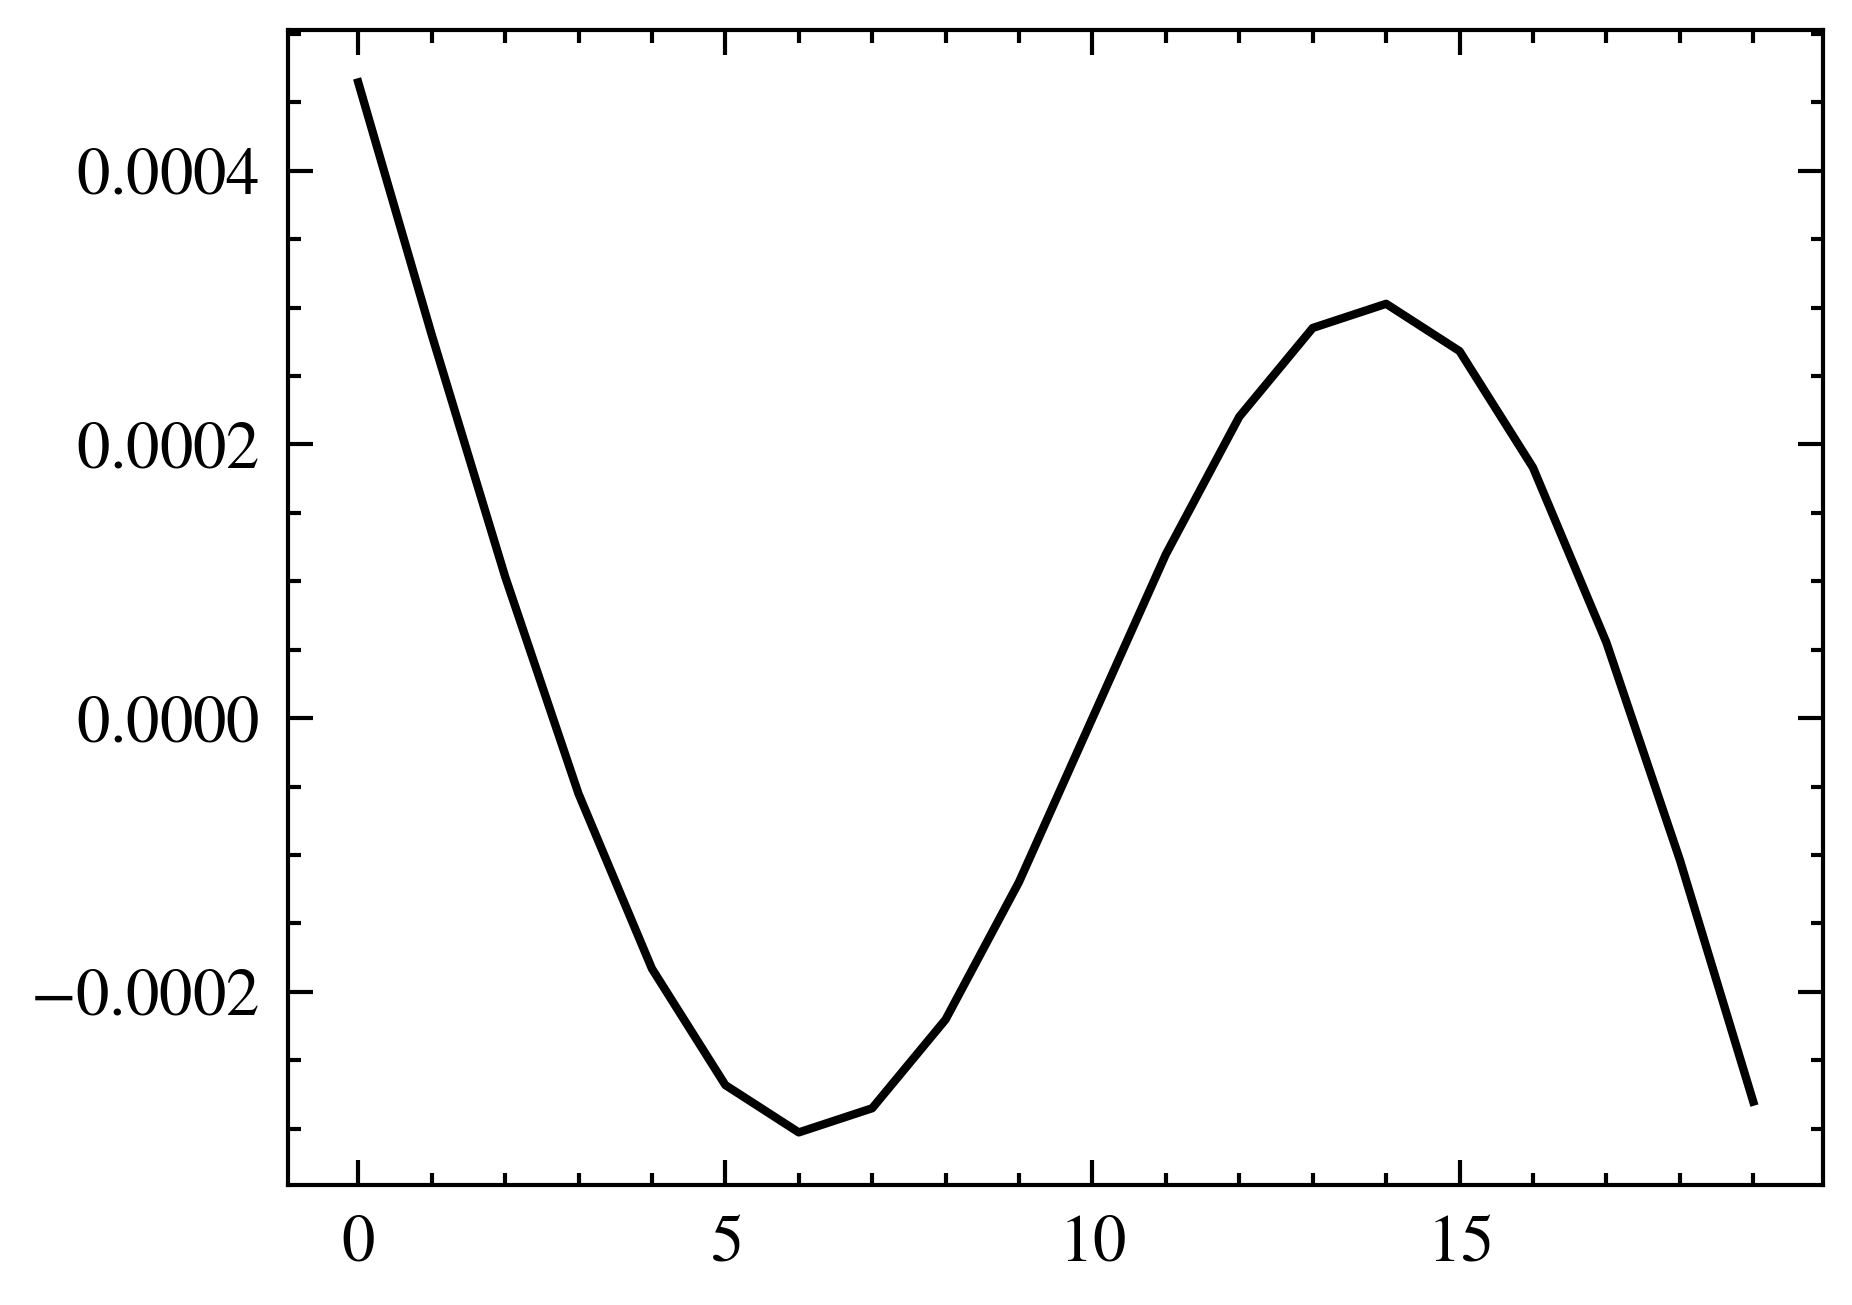

In [18]:
#该部分只用于检查，可不运行
import numpy as np
from scipy.linalg import eigh
eigenvalues, eigenvectors = eigh(k, M)
print(eigenvalues[6:20])
mid = eigenvectors[22*5-5:42*5-5,:]
import matplotlib.pyplot as plt
plt.plot(mid[2::5,6])